# EMPLOYEE PERFORMANCE PREDICTION
---
**KCE081BCT012 — DATA SCIENCE PROJECT**  

---

### PROBLEM STATEMENT

In many organizations, predicting employee performance is difficult because it depends on various factors like job satisfaction, work-life balance, income, overtime, and years of experience.

This project builds a **Machine Learning model** to predict an employee's **Performance Rating (3 = Good, 4 = Excellent)** based on IBM HR dataset.

---

### OBJECTIVES
- To predict Employee Performance

---

### DATASET SUMMARY


- **Source:** IBM HR Analytics Employee Attrition & Performance ([Kaggle](https://www.kaggle.com/code/faressayah/ibm-hr-analytics-employee-attrition-performance))
- **Rows:** 1,470 
- **Columns:** 35
- **Target Variable:** `PerformanceRating` 
- **Type:** Real-world IBM HR data

---

### Feature Description

| Feature | Type | Description |
|---|---|---|
| `Age` | Numeric | Age of the employee in years.  |
| `Attrition` | Categorical | Whether the employee left the company. Yes = Left, No = Still working. |
| `BusinessTravel` | Categorical | Frequency of business travel. Three categories: Non-Travel, Travel Rarely, Travel Frequently. |
| `DailyRate` | Numeric | Daily salary rate of the employee in dollars. |
| `Department` | Categorical | Department where the employee works. Three departments: Human Resources, Research & Development, Sales. |
| `DistanceFromHome` | Numeric | Distance in km between employee's home and office.|
| `Education` | Ordinal | Highest education level.  |
| `EducationField` | Categorical | Field of study. Six categories: Life Sciences, Medical, Marketing, Technical Degree, Human Resources, Other. |
| `EnvironmentSatisfaction` | Ordinal | Employee's satisfaction with work environment. |
| `Gender` | Categorical | Gender of the employee. Male or Female. |
| `HourlyRate` | Numeric | Hourly salary rate of the employee. |
| `JobInvolvement` | Ordinal | Level of involvement in the job.  |
| `JobLevel` | Ordinal | Job seniority level. |
| `JobRole` | Categorical | Specific job title.  |
| `JobSatisfaction` | Ordinal | Employee's satisfaction with their job.  |
| `MaritalStatus` | Categorical | Marital status of employee.  |
| `MonthlyIncome` | Numeric | Monthly salary of the employee in dollars. |
| `MonthlyRate` | Numeric | Monthly rate assigned to the employee. |
| `NumCompaniesWorked` | Numeric | Total number of companies the employee worked at before IBM. |
| `OverTime` | Categorical | Whether the employee works overtime. Yes or No. |
| `PercentSalaryHike` | Numeric | Percentage salary increase last year. Ranges from 11% to 25%. |
| `PerformanceRating` | Ordinal | **Target Variable.** Employee performance rating. 3 = Good, 4 = Excellent. |
| `RelationshipSatisfaction` | Ordinal | Satisfaction with work relationships.  |
| `StockOptionLevel` | Ordinal | Level of stock options granted.  |
| `TotalWorkingYears` | Numeric | Total years of professional work experience. |
| `TrainingTimesLastYear` | Numeric | Number of training sessions attended last year. |
| `WorkLifeBalance` | Ordinal | Employee's work-life balance rating. |
| `YearsAtCompany` | Numeric | Number of years the employee has worked at IBM. |
| `YearsInCurrentRole` | Numeric | Number of years in current job role. |
| `YearsSinceLastPromotion` | Numeric | Number of years since last promotion.|
| `YearsWithCurrManager` | Numeric | Number of years working under current manager.|

---



### EDA (Exploratory Data Analysis)

In Model Training Step,

First we need to Understand the dataset what problems and errors does it contains then we must handel the error present in  data by applying diferent approaches.

---

##  Importing Important Libraries

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler




- Pandas is required for reading, modifying and analyzing the data.
- Numpy is necessary for Efficient and faster mathematical calculations.
- Matplotlib helps to create basis graphs and charts.(Pyplot is the module of matplotlib it is the simple plotting function)
- Seaborn is the advanced visualization library which helps in Statistical data visualization.
- skikit-learn is the ML preprocessing module which helps in Data scaling and Encoding.

This all libraries are necessary for our Project.
 
---

##  Loading Dataset

In [68]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')


The dataset is loaded from a CSV file using pandas read_csv() function.

CSV is the comma separated value raw form of data, using read_csv() it automatically convert raw form of data into structured form as it is assigned to df variable. The df contains the structured dataset.

---

In [69]:
print("Rows:",df.shape[0])
print("Columns:",df.shape[1])


Rows: 1470
Columns: 35


Our dataset has 1470 rows (employees) and 35 columns (features).

---

In [70]:
df.head(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


df.head() displays the first 5 rows of the dataset.
This gives us a quick preview of the data and column values.

---

In [71]:
df.tail(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


df.tail() displays the last 5 rows.
This helps confirm the data is loaded completely without any truncation.

---

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [73]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

df.info() shows:
- Column names
- Datatype of each column (int, object)
- Number of non-null values

Key Findings is that, Every feature has 1470  data i.e. no missing value, from isnull().sum() it is confirmed that no null values.

- There are 26 features with int data types
- There are 9 features with object datatypes

Thus, our dataset contains no missing values, so we further donot need to handel missing values.

Checking Data Redundancy

In [74]:
duplicate_rows=df.duplicated().sum()
print("Number of duplicate rows:",duplicate_rows)

Number of duplicate rows: 0


Thus, Output shows that there is no redudancy in dataset. Means Data Duplication handeling process is not required.

Checking unique Value in each Column

In [75]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EmployeeCount                  1
EmployeeNumber              1470
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
Over18                         1
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StandardHours                  1
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBa



###  Columns To Be Dropped

| Feature | Reason |
|---|---|
| `EmployeeCount` | Always = 1 for every employee — no information |
| `EmployeeNumber` | Just a unique ID — not a real feature |
| `Over18` | Always = Y for every employee — no information |
| `StandardHours` | Always = 80 for every employee — no information |

In [76]:

constant_cols = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
print("Dropping constant/ID columns:", constant_cols)
df = df.drop(columns=constant_cols)
print(f"Shape after dropping: {df.shape}")

Dropping constant/ID columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Shape after dropping: (1470, 31)


In [77]:
df.nunique()

Age                           43
Attrition                      2
BusinessTravel                 3
DailyRate                    886
Department                     3
DistanceFromHome              29
Education                      5
EducationField                 6
EnvironmentSatisfaction        4
Gender                         2
HourlyRate                    71
JobInvolvement                 4
JobLevel                       5
JobRole                        9
JobSatisfaction                4
MaritalStatus                  3
MonthlyIncome               1349
MonthlyRate                 1427
NumCompaniesWorked            10
OverTime                       2
PercentSalaryHike             15
PerformanceRating              2
RelationshipSatisfaction       4
StockOptionLevel               4
TotalWorkingYears             40
TrainingTimesLastYear          7
WorkLifeBalance                4
YearsAtCompany                37
YearsInCurrentRole            19
YearsSinceLastPromotion       16
YearsWithC

Thus, from nunique() output it is clear that column with unnecessary unique value feature is dropped.

---

### Checking Outliers (Using Boxplot)

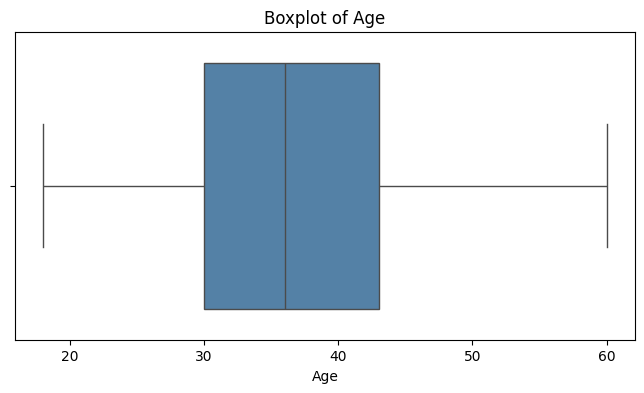

In [78]:

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Age'], color='steelblue')
plt.title('Boxplot of Age')
plt.xlabel('Age')
plt.show()

The boxplot of Age shows the distribution between 18–60 years. The median is around 36. No whisker points fall outside the bounds, confirming no outliers in Age.

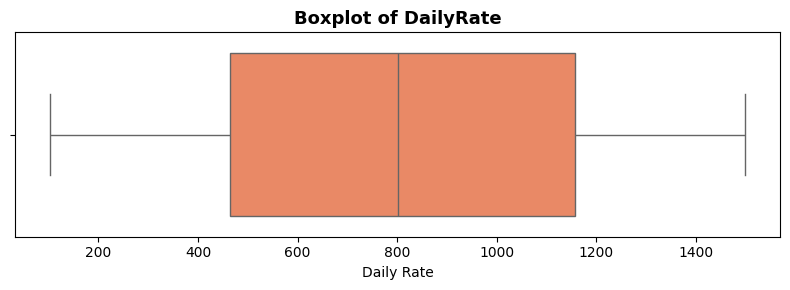

In [79]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['DailyRate'], color='coral')
plt.title('Boxplot of DailyRate', fontsize=13, fontweight='bold')
plt.xlabel('Daily Rate')
plt.tight_layout()
plt.show()

 DailyRate is fairly uniformly distributed between 100 and 1500. No significant outliers detected.

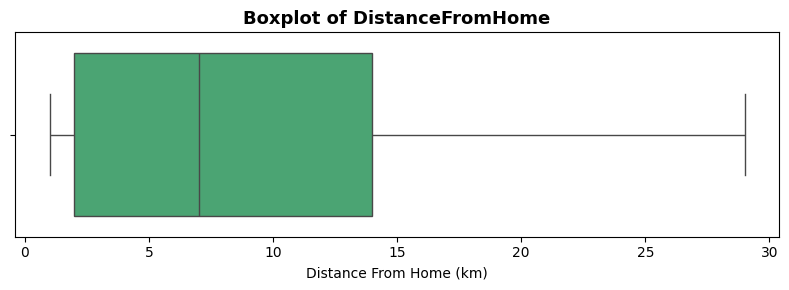

In [80]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['DistanceFromHome'], color='mediumseagreen')
plt.title('Boxplot of DistanceFromHome', fontsize=13, fontweight='bold')
plt.xlabel('Distance From Home (km)')
plt.tight_layout()
plt.show()

 Most employees live within 10 km of the office. A few employees live very far (25-29 km) — these appear as mild outliers.

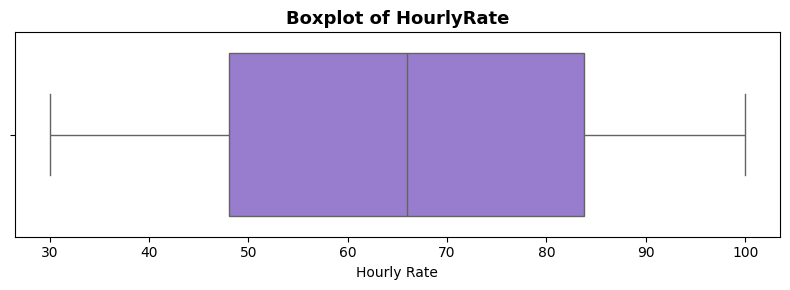

In [81]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['HourlyRate'], color='mediumpurple')
plt.title('Boxplot of HourlyRate', fontsize=13, fontweight='bold')
plt.xlabel('Hourly Rate')
plt.tight_layout()
plt.show()

 HourlyRate ranges from 30 to 100. Distribution is approximately uniform with no extreme outliers.

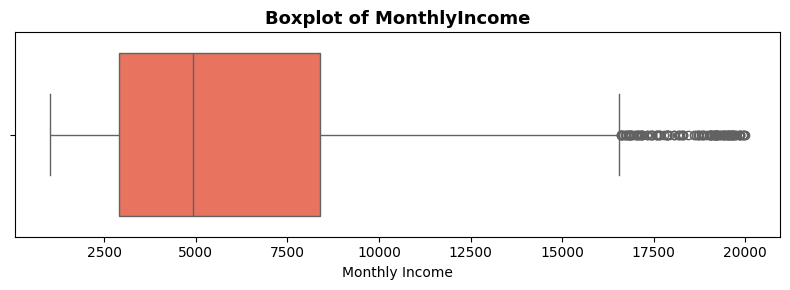

In [82]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['MonthlyIncome'], color='tomato')
plt.title('Boxplot of MonthlyIncome', fontsize=13, fontweight='bold')
plt.xlabel('Monthly Income')
plt.tight_layout()
plt.show()

 MonthlyIncome is right skewed. Most employees earn between 2000–8000. A few high earners (above 15000) appear as outliers — these are likely senior managers or directors.

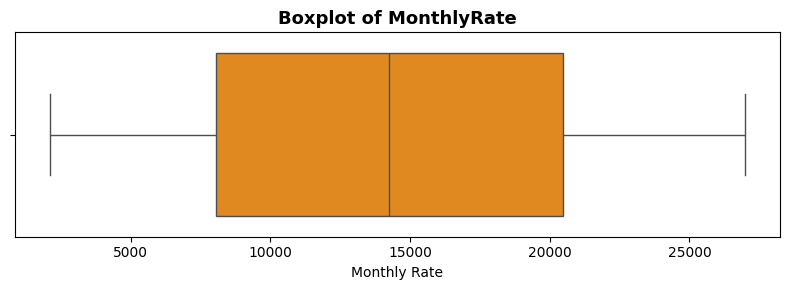

In [83]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['MonthlyRate'], color='darkorange')
plt.title('Boxplot of MonthlyRate', fontsize=13, fontweight='bold')
plt.xlabel('Monthly Rate')
plt.tight_layout()
plt.show()

 MonthlyRate is uniformly distributed between 2000 and 27000. No significant outliers detected.

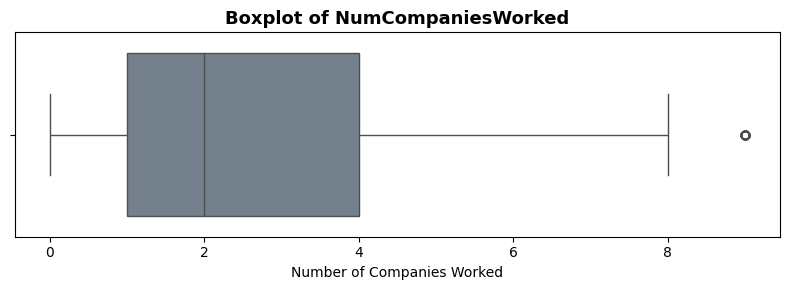

In [84]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['NumCompaniesWorked'], color='slategray')
plt.title('Boxplot of NumCompaniesWorked', fontsize=13, fontweight='bold')
plt.xlabel('Number of Companies Worked')
plt.tight_layout()
plt.show()

 Most employees have worked in 0–4 companies. Employees who worked in 8–9 companies appear as mild outliers — indicating high job-hopping behavior.

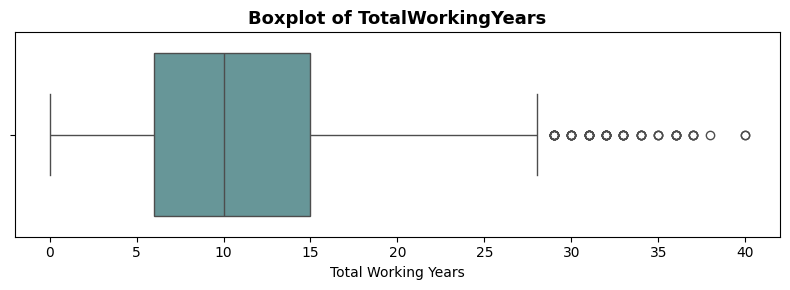

In [85]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['TotalWorkingYears'], color='cadetblue')
plt.title('Boxplot of TotalWorkingYears', fontsize=13, fontweight='bold')
plt.xlabel('Total Working Years')
plt.tight_layout()
plt.show()

 Most employees have 5–15 years of total experience. A few highly experienced employees (35–40 years) appear as outliers on the right side.

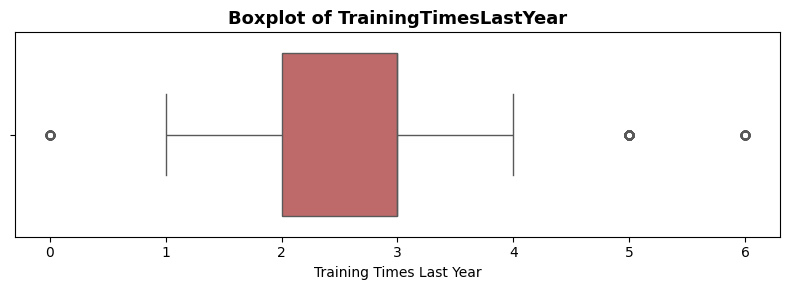

In [86]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['TrainingTimesLastYear'], color='indianred')
plt.title('Boxplot of TrainingTimesLastYear', fontsize=13, fontweight='bold')
plt.xlabel('Training Times Last Year')
plt.tight_layout()
plt.show()

 Most employees attended 2–4 training sessions last year. Employees with 0 or 6 training sessions appear as mild outliers.

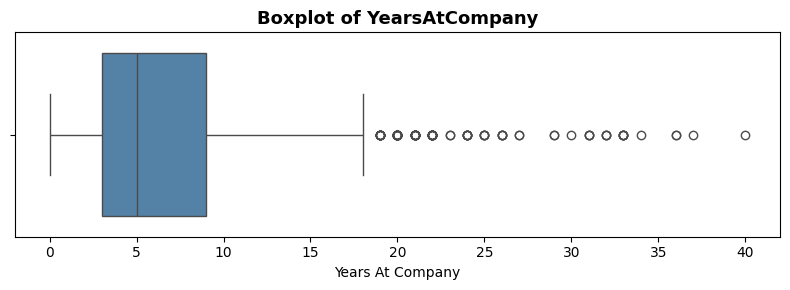

In [87]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['YearsAtCompany'], color='steelblue')
plt.title('Boxplot of YearsAtCompany', fontsize=13, fontweight='bold')
plt.xlabel('Years At Company')
plt.tight_layout()
plt.show()

 Most employees have been at the company for 1–10 years. A few long-serving employees (30–40 years) appear as extreme outliers on the right.

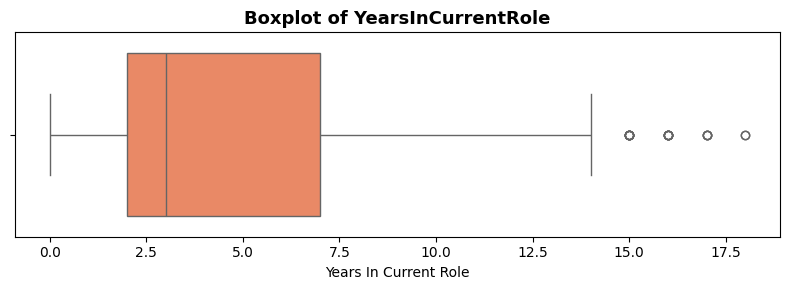

In [88]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['YearsInCurrentRole'], color='coral')
plt.title('Boxplot of YearsInCurrentRole', fontsize=13, fontweight='bold')
plt.xlabel('Years In Current Role')
plt.tight_layout()
plt.show()

 Most employees have been in their current role for 0–7 years. Employees with 15–18 years in the same role appear as outliers.

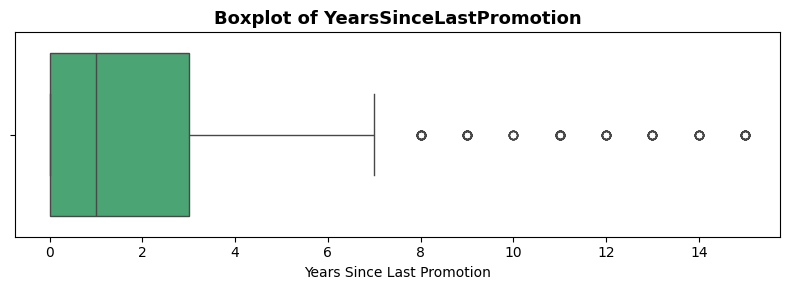

In [89]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['YearsSinceLastPromotion'], color='mediumseagreen')
plt.title('Boxplot of YearsSinceLastPromotion', fontsize=13, fontweight='bold')
plt.xlabel('Years Since Last Promotion')
plt.tight_layout()
plt.show()

 Most employees were promoted within the last 2 years. Employees who have not been promoted for 12–15 years appear as strong outliers — this may indicate inactive career growth.

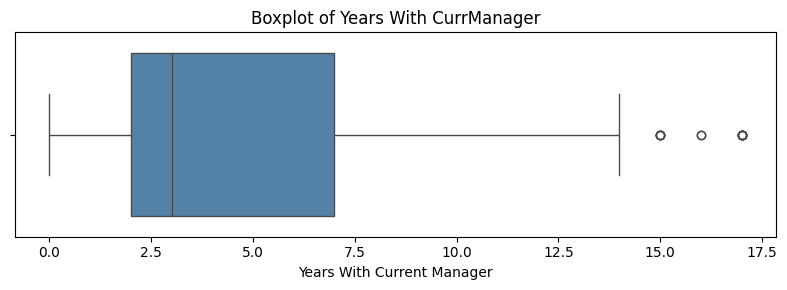

In [90]:
plt.figure(figsize=(8, 3))
sns.boxplot(x=df['YearsWithCurrManager'], color='steelblue')
plt.title('Boxplot of Years With CurrManager')
plt.xlabel('Years With Current Manager')
plt.tight_layout()
plt.show()

 Most employees have worked with their current manager for 0–7 years. A few employees with 14–17 years under the same manager appear as outliers — indicating very long stable reporting relationships.

## Step 5: Outlier Handling

**Purpose:** From the boxplots above, 8 features were found to have outliers.
We handle them using IQR Capping method to preserve all 1470 rows.

In [91]:
outlier_cols = ['MonthlyIncome', 'NumCompaniesWorked', 'TotalWorkingYears',
                'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole',
                'YearsSinceLastPromotion', 'YearsWithCurrManager']

In [92]:
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower, upper)

print("Outliers capped successfully!")
print(f"Shape: {df.shape}  — No rows removed!")

Outliers capped successfully!
Shape: (1470, 31)  — No rows removed!


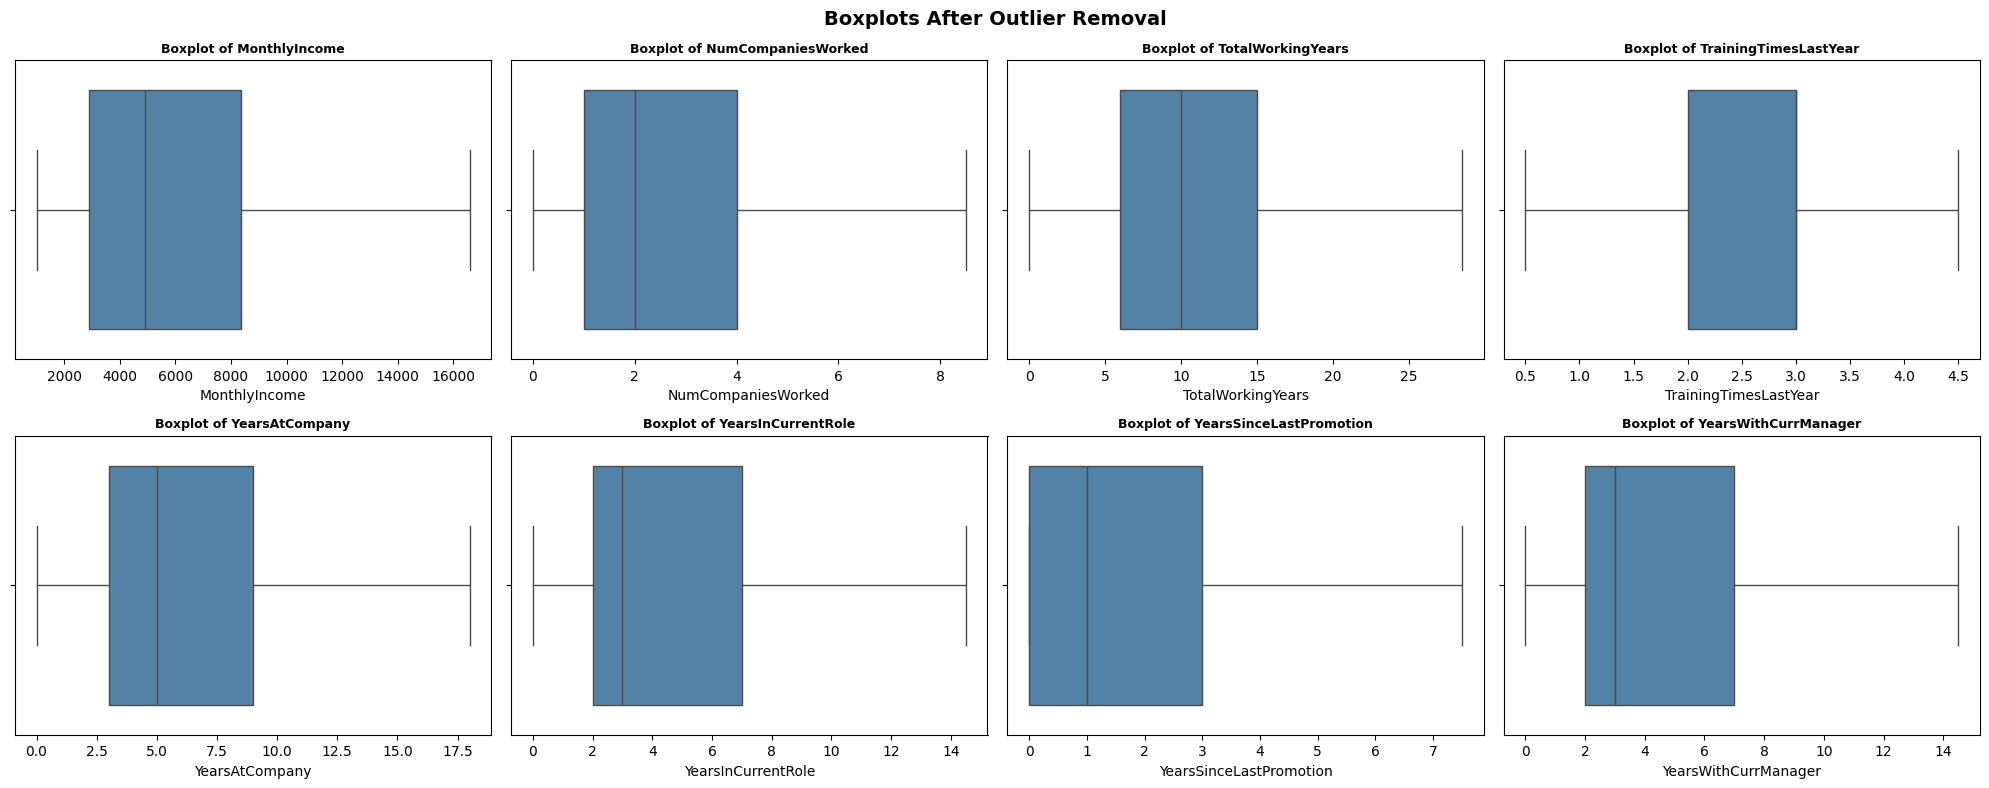

In [93]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(outlier_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Boxplot of {col}', fontsize=9, fontweight='bold')

plt.suptitle('Boxplots After Outlier Removal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

After applying IQR Capping ,All 1470 rows are preserved. No data was lost.
Outliers are fully handled

## Feature Distribution

Histogram

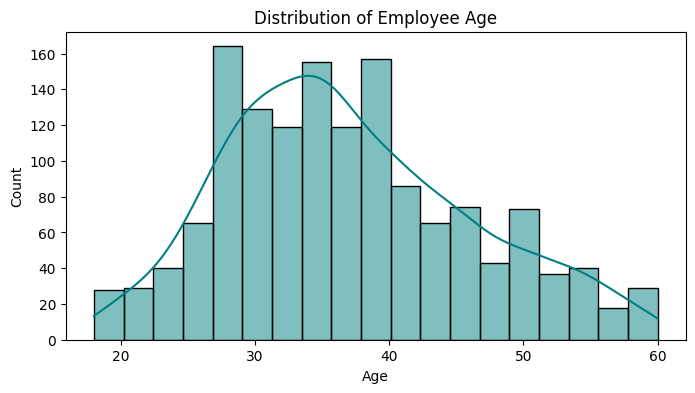

In [94]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], kde=True, color='teal')
plt.title('Distribution of Employee Age')
plt.show()


Age is approximately normally distributed with most employees between 28–42 years. The KDE curve shows a slight right skew. No transformation needed.


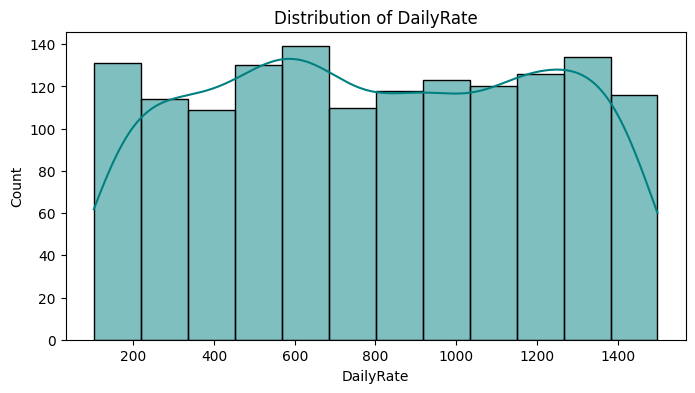

In [95]:
plt.figure(figsize=(8, 4))
sns.histplot(df['DailyRate'], kde=True, color='teal')
plt.title('Distribution of DailyRate')
plt.show()

DailyRate is approximately uniform — almost equal number of employees at every rate between 100–1500. The flat KDE line confirms this. No transformation needed.

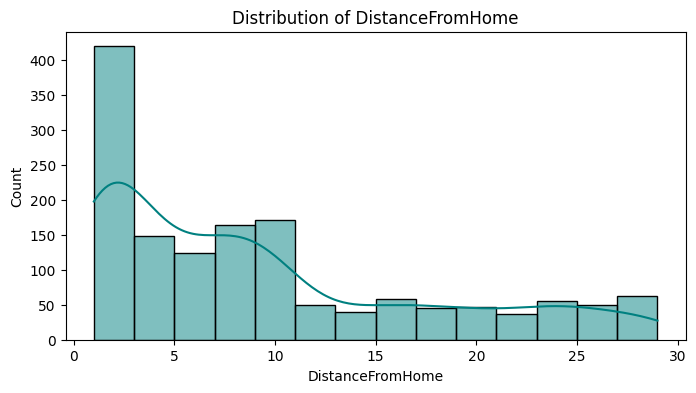

In [96]:
plt.figure(figsize=(8, 4))
sns.histplot(df['DistanceFromHome'], kde=True, color='teal')
plt.title('Distribution of DistanceFromHome')
plt.show()

Most employees live within 1–10 km of the office. Distribution is right skewed — very few employees live 25–29 km away.

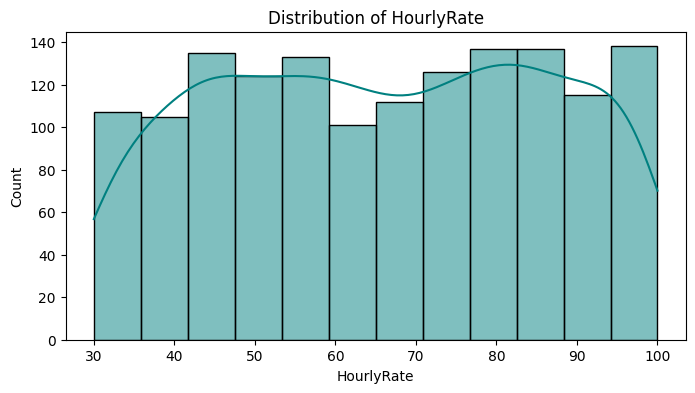

In [97]:
plt.figure(figsize=(8, 4))
sns.histplot(df['HourlyRate'], kde=True, color='teal')
plt.title('Distribution of HourlyRate')
plt.show()

HourlyRate is approximately uniform between 30–100. The flat KDE line confirms even distribution. No transformation needed.

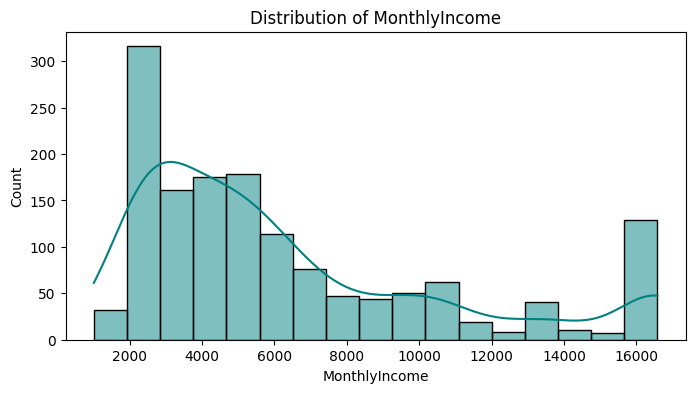

In [98]:
plt.figure(figsize=(8, 4))
sns.histplot(df['MonthlyIncome'], kde=True, color='teal')
plt.title('Distribution of MonthlyIncome')
plt.show()

MonthlyIncome is right skewed — most employees earn between 2000–8000. 
Few high earners exist up to 19999 (likely senior managers or directors). 
The long right tail in the KDE curve confirms high skewness. 
Outliers were handled using IQR Capping in the previous step.

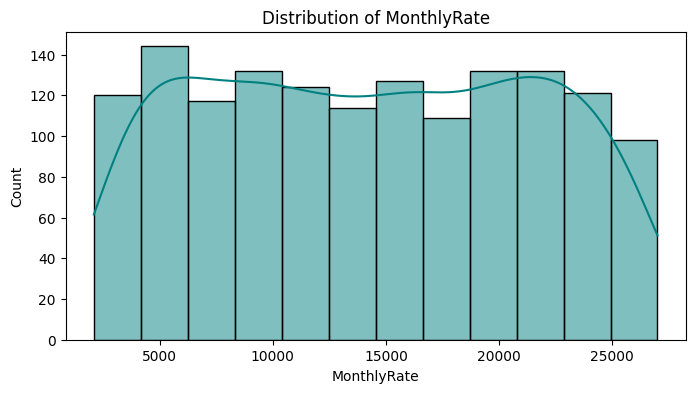

In [99]:
plt.figure(figsize=(8, 4))
sns.histplot(df['MonthlyRate'], kde=True, color='teal')
plt.title('Distribution of MonthlyRate')
plt.show()

MonthlyRate is approximately uniform between 2000–27000. No skewness — no transformation needed.

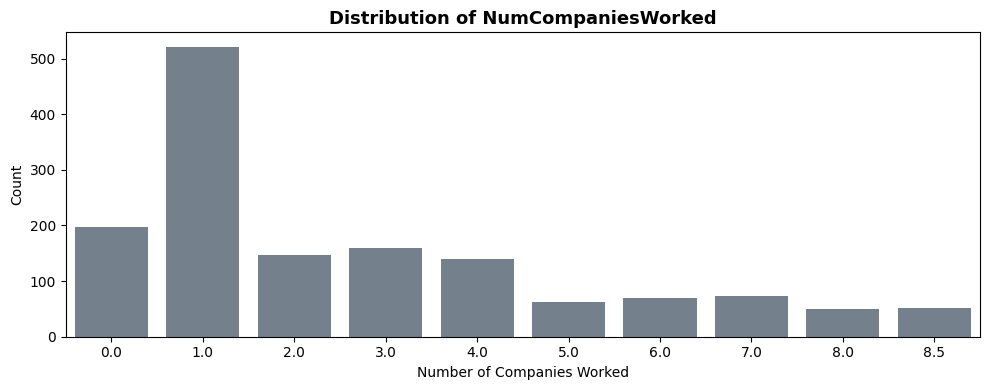

In [100]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='NumCompaniesWorked', color='slategray')
plt.title('Distribution of NumCompaniesWorked', fontsize=13, fontweight='bold')
plt.xlabel('Number of Companies Worked')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most employees worked at only 1 company before IBM. Very fewworked at 8–9 companies. Right skewed distribution — outliers were handled using IQRCapping.

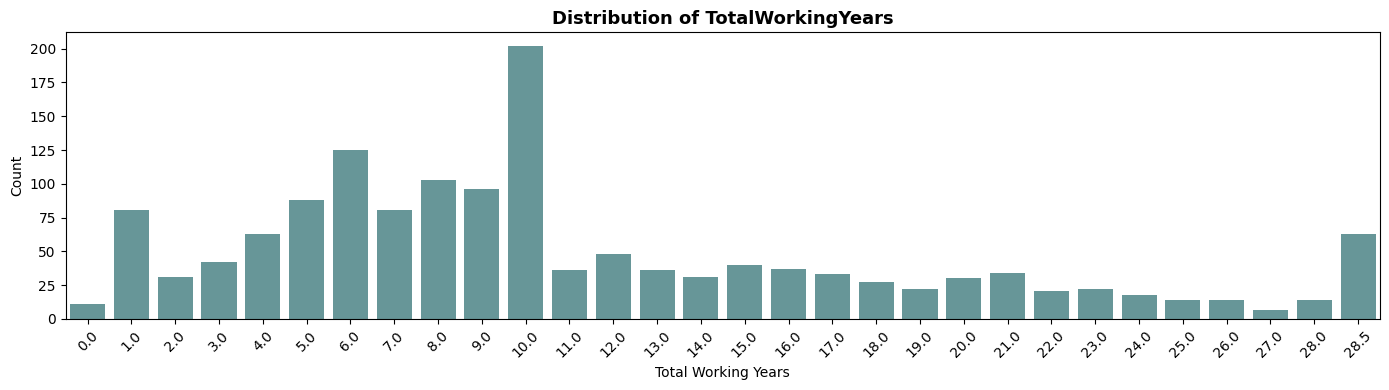

In [101]:
plt.figure(figsize=(14, 4))
sns.countplot(data=df, x='TotalWorkingYears', color='cadetblue')
plt.title('Distribution of TotalWorkingYears', fontsize=13, fontweight='bold')
plt.xlabel('Total Working Years')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most employees have 5–10 years of total experience. Very experienced employees (30–40 years) are rare. Right skewed distribution — outliers were handled using IQR Capping.

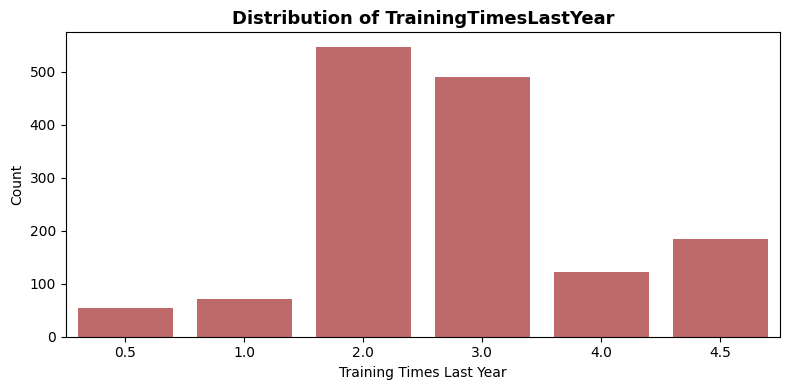

In [102]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='TrainingTimesLastYear', color='indianred')
plt.title('Distribution of TrainingTimesLastYear', fontsize=13, fontweight='bold')
plt.xlabel('Training Times Last Year')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most employees attended 2–3 training sessions last year. Very few attended 0 or 6 sessions. Distribution is approximately normal around 3 sessions.

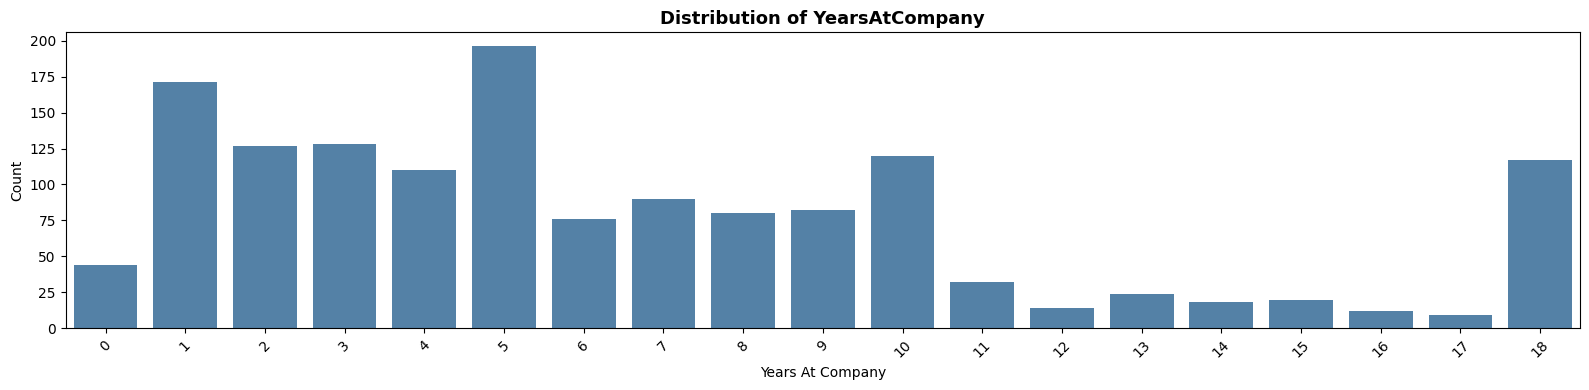

In [103]:
plt.figure(figsize=(16, 4))
sns.countplot(data=df, x='YearsAtCompany', color='steelblue')
plt.title('Distribution of YearsAtCompany', fontsize=13, fontweight='bold')
plt.xlabel('Years At Company')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Most employees have been at IBM for 1–5 years. Very few stayed for 30–40 years. Highly right skewed distribution — outliers were handled using IQR Capping.

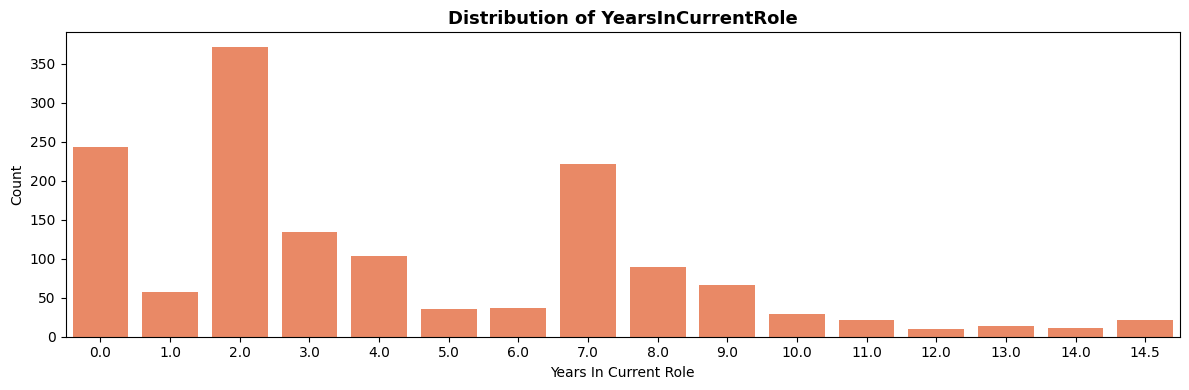

In [104]:
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='YearsInCurrentRole', color='coral')
plt.title('Distribution of YearsInCurrentRole', fontsize=13, fontweight='bold')
plt.xlabel('Years In Current Role')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most employees have been in their current role for 0–4 years. Few stayed in the same role for 15–18 years — indicating limited role mobility.

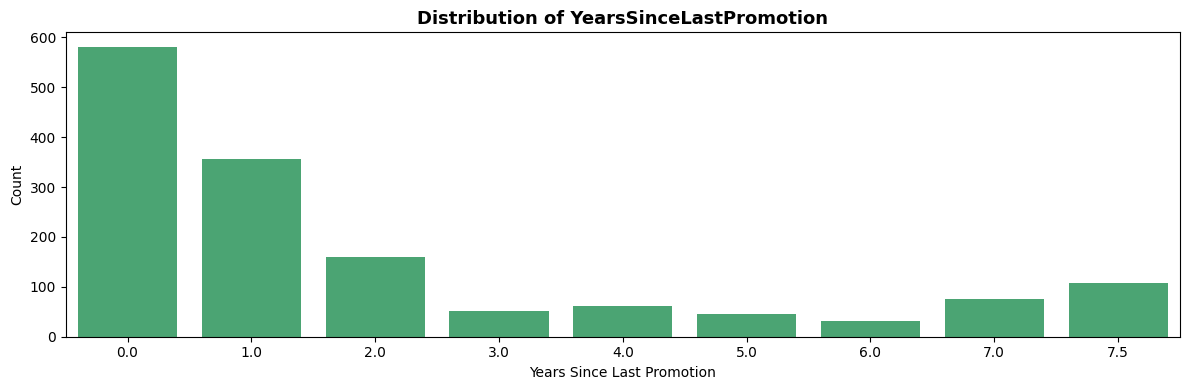

In [105]:
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='YearsSinceLastPromotion', color='mediumseagreen')
plt.title('Distribution of YearsSinceLastPromotion', fontsize=13, fontweight='bold')
plt.xlabel('Years Since Last Promotion')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most employees were promoted within the last 1–2 years. Some employees have not been promoted for 12–15 years — indicating stagnant career growth. Highly skewed distribution — outliers were handled using IQR Capping.

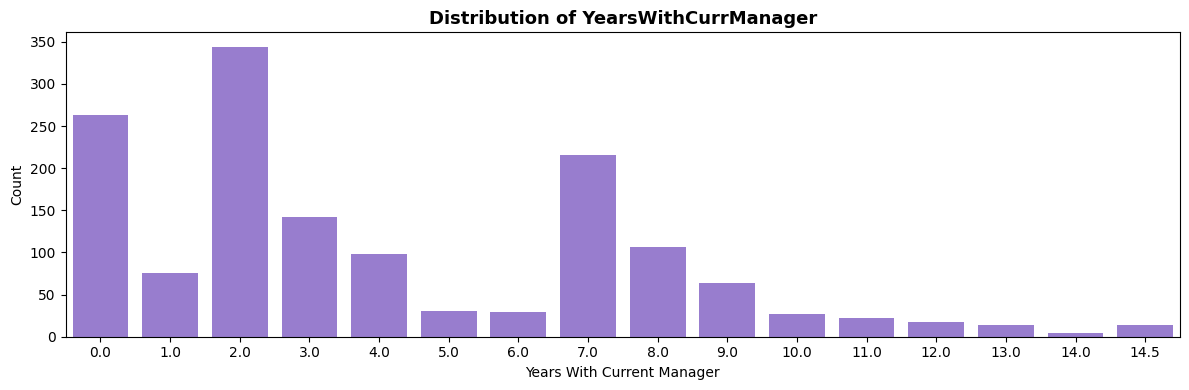

In [106]:
plt.figure(figsize=(12, 4))
sns.countplot(data=df, x='YearsWithCurrManager', color='mediumpurple')
plt.title('Distribution of YearsWithCurrManager', fontsize=13, fontweight='bold')
plt.xlabel('Years With Current Manager')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most employees have worked with their current manager for 0–4 years. A few with 14–17 years under the same manager indicate very stable long-term relationships.


C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\1993157829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Department', palette='Set2')


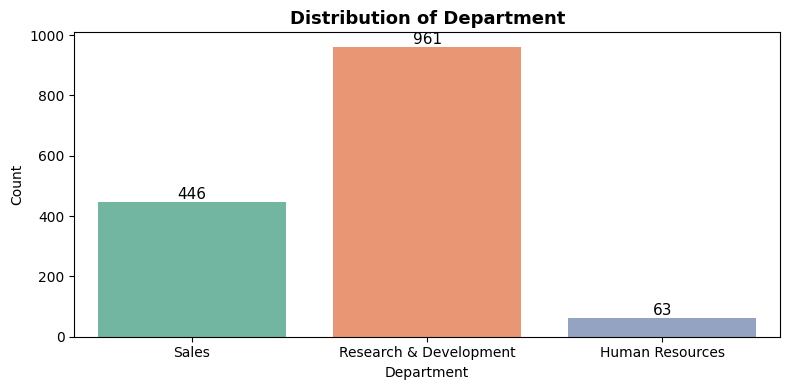

In [107]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='Department', palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Distribution of Department', fontsize=13, fontweight='bold')
plt.xlabel('Department')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Research & Development is the largest department (65%). Sales is second (30%). Human Resources is smallest (5%).

C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\467037159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Gender', palette='Set1')


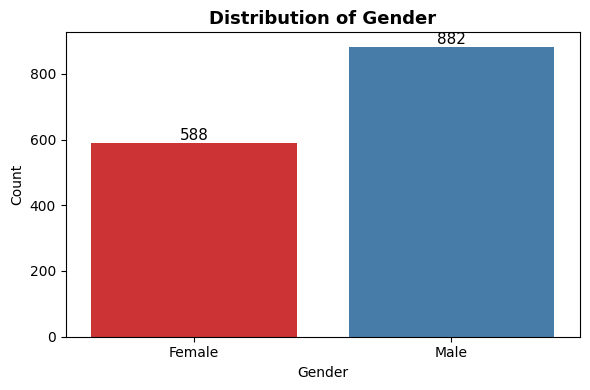

In [108]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='Gender', palette='Set1')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Distribution of Gender', fontsize=13, fontweight='bold')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Male employees (882 = 60%) outnumber Female employees (588 = 40%). Mild gender imbalance exists.

C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\639818347.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='OverTime', palette='Set3')


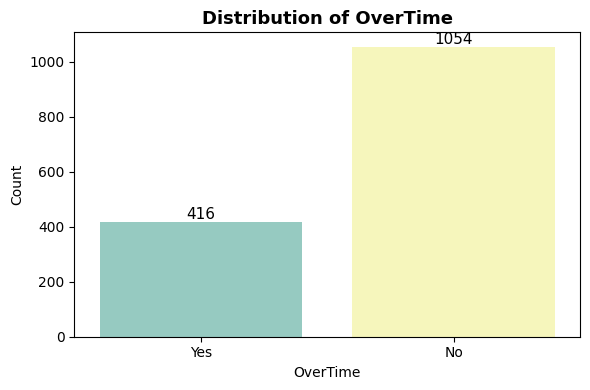

In [109]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='OverTime', palette='Set3')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Distribution of OverTime', fontsize=13, fontweight='bold')
plt.xlabel('OverTime')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

72% of employees do NOT work overtime. Only 28% work overtime. Most IBM employees maintain regular working hours.

C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\3522719399.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='BusinessTravel', palette='Set2')


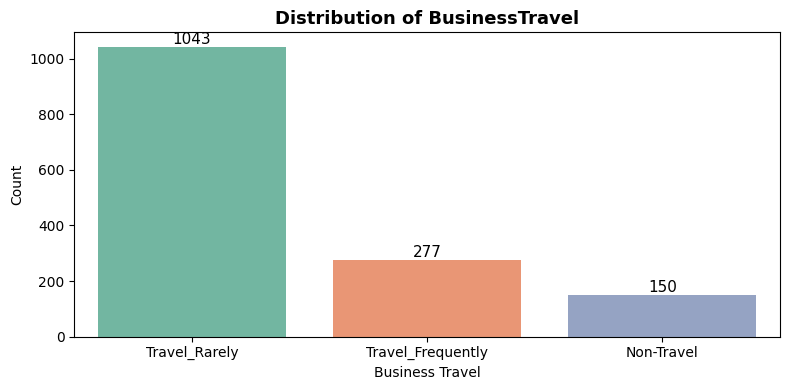

In [110]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='BusinessTravel', palette='Set2')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Distribution of BusinessTravel', fontsize=13, fontweight='bold')
plt.xlabel('Business Travel')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most employees travel rarely for business. Very few travel frequently. Non-travel employees are the least common.

C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\2566356427.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='MaritalStatus', palette='pastel')


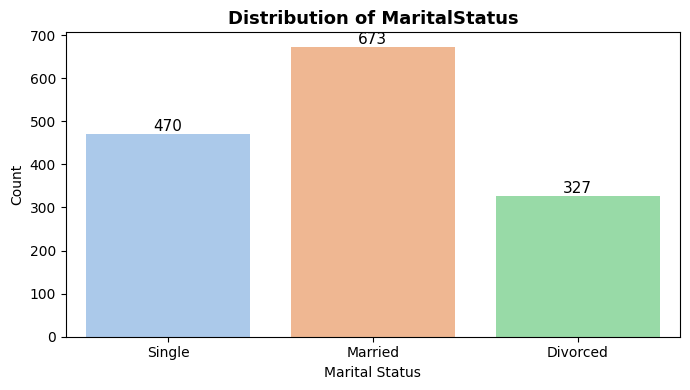

In [111]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='MaritalStatus', palette='pastel')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.title('Distribution of MaritalStatus', fontsize=13, fontweight='bold')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Married employees are the majority. Single employees are second. Divorced employees are the least common.


C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\2416501850.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='JobRole', palette='tab10')


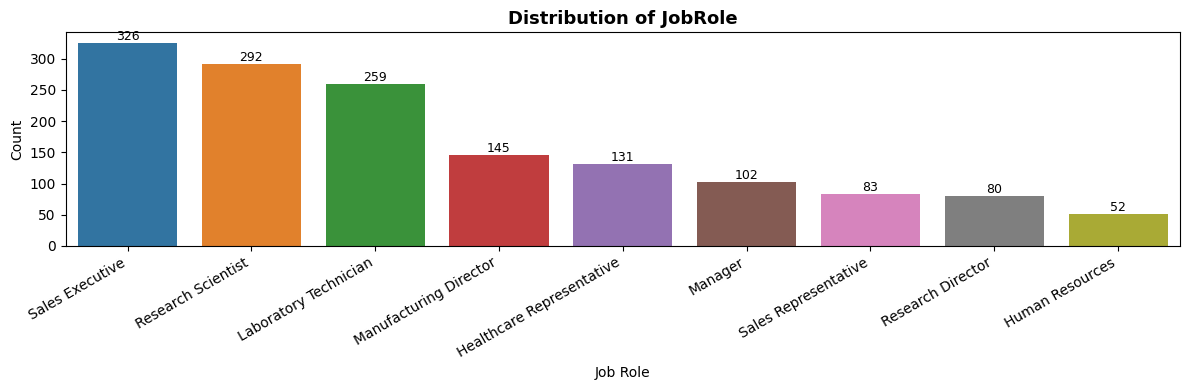

In [112]:
plt.figure(figsize=(12, 4))
ax = sns.countplot(data=df, x='JobRole', palette='tab10')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.title('Distribution of JobRole', fontsize=13, fontweight='bold')
plt.xlabel('Job Role')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

Sales Executive and Research Scientist are the most common roles. Human Resources and Research Director are the least common. 9 different job roles exist.

C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\525837794.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Education', palette='Blues_d')
C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\525837794.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Below College(1)','College(2)','Bachelor(3)','Master(4)','Doctor(5)'])


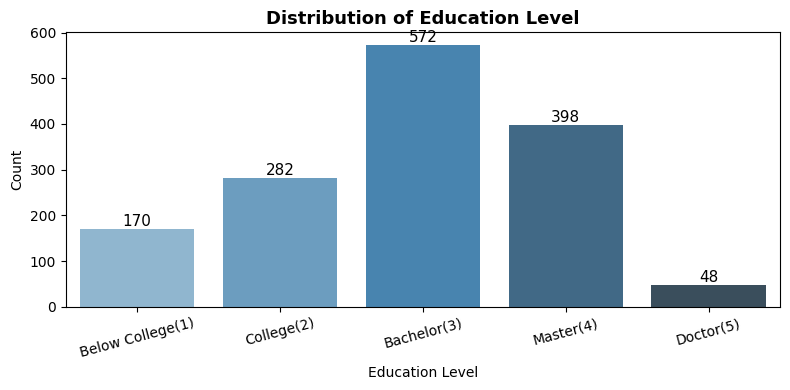

In [113]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x='Education', palette='Blues_d')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_xticklabels(['Below College(1)','College(2)','Bachelor(3)','Master(4)','Doctor(5)'])
plt.title('Distribution of Education Level', fontsize=13, fontweight='bold')
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

Most employees hold a Bachelor's degree (3). Master's degree is second most common. Very few have a Doctorate. IBM employs highly educated professionals.

C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\1646161774.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='JobSatisfaction', palette='RdYlGn')
C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\1646161774.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Low(1)','Medium(2)','High(3)','Very High(4)'])


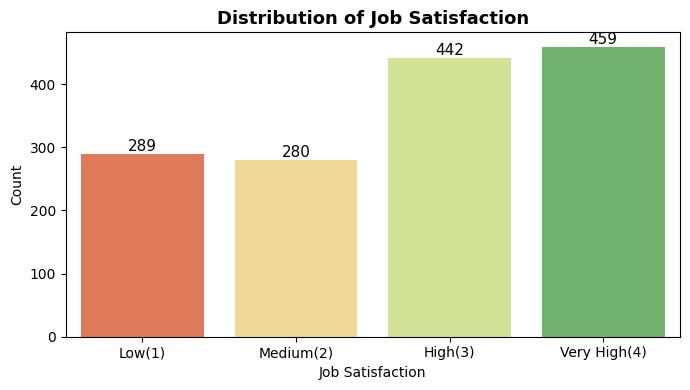

In [114]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='JobSatisfaction', palette='RdYlGn')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_xticklabels(['Low(1)','Medium(2)','High(3)','Very High(4)'])
plt.title('Distribution of Job Satisfaction', fontsize=13, fontweight='bold')
plt.xlabel('Job Satisfaction')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Job satisfaction is fairly evenly distributed. High (3) and Very High (4) satisfaction are most common — showing most IBM employees are reasonably satisfied with their work.

C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\1429419315.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='WorkLifeBalance', palette='coolwarm')
C:\Users\DDIP\AppData\Local\Temp\ipykernel_9036\1429419315.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Bad(1)','Good(2)','Better(3)','Best(4)'])


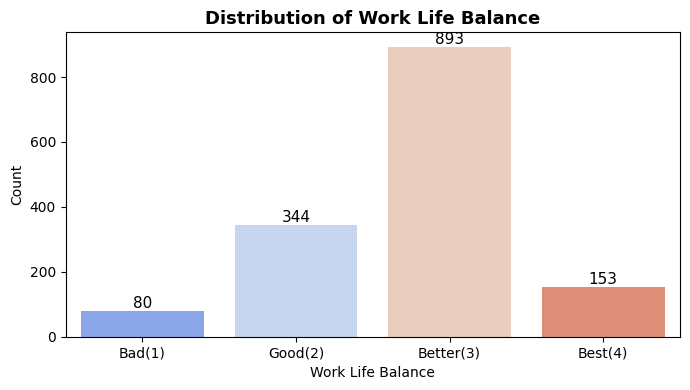

In [115]:
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df, x='WorkLifeBalance', palette='coolwarm')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x()+p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=11)
ax.set_xticklabels(['Bad(1)','Good(2)','Better(3)','Best(4)'])
plt.title('Distribution of Work Life Balance', fontsize=13, fontweight='bold')
plt.xlabel('Work Life Balance')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most employees rate their work-life balance as Better (3). Very few rate it as Bad (1). IBM generally provides a good work-life balance to its employees.

### Correlation Analysis Using Heatmap

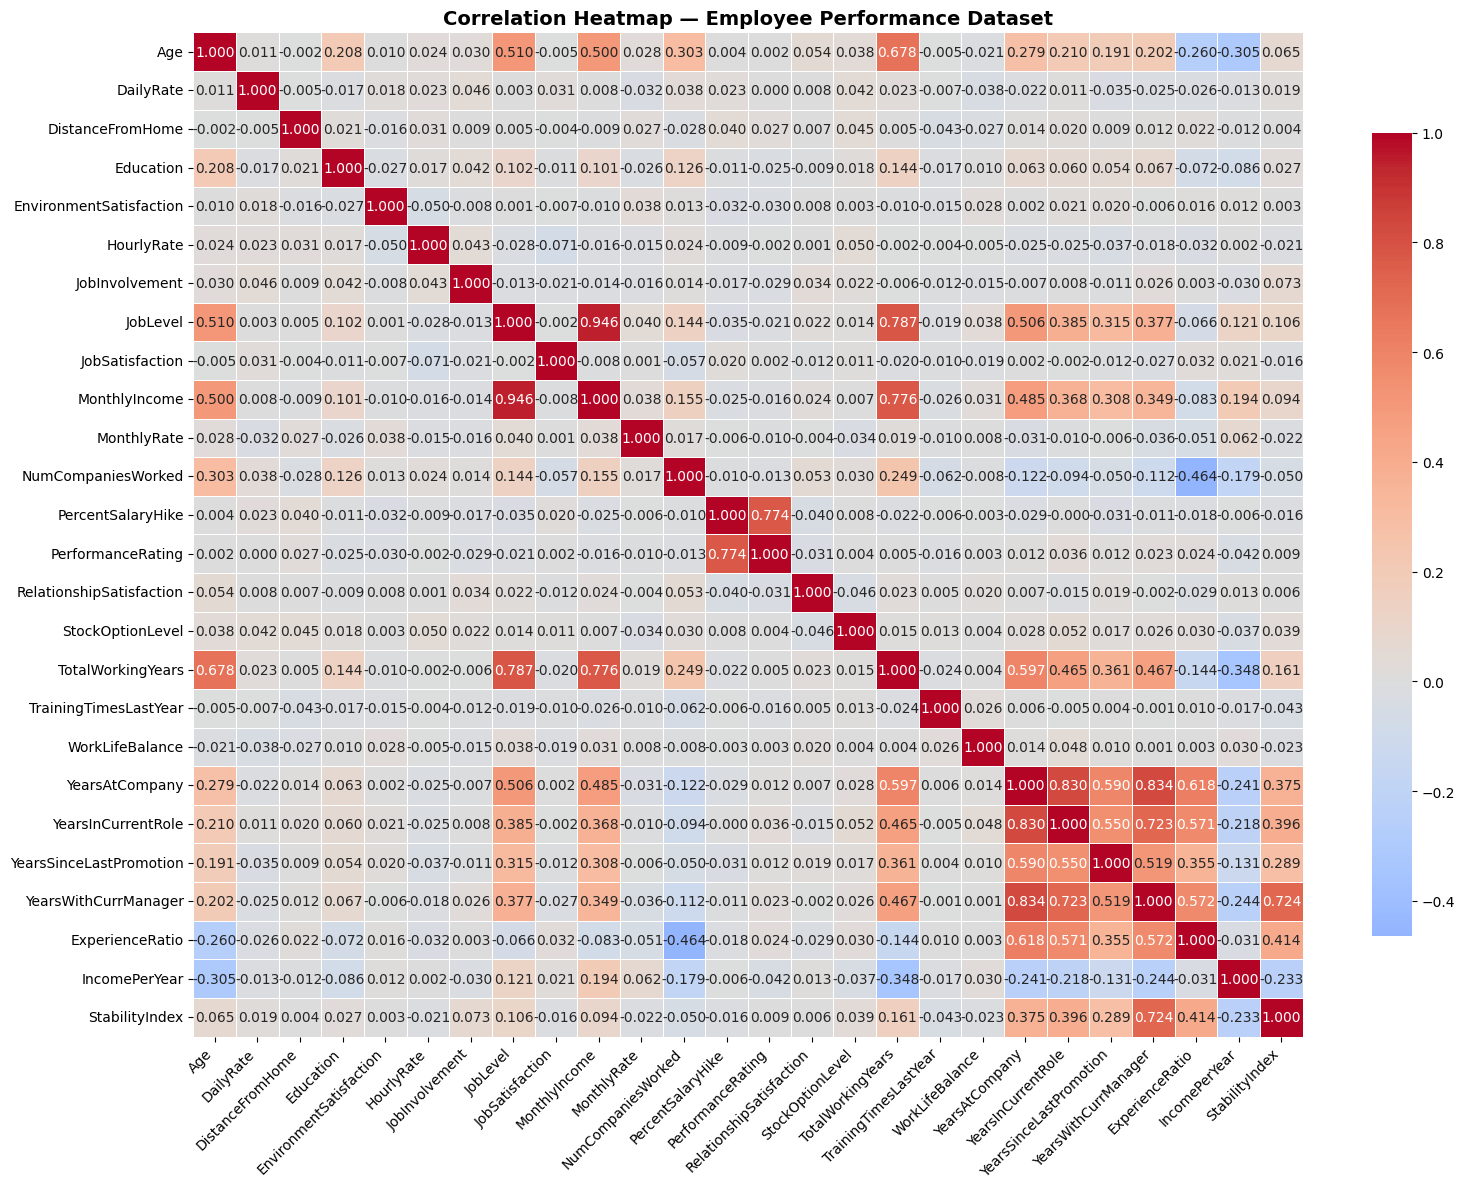

In [125]:
plt.figure(figsize=(16, 12))
corr_df = df.select_dtypes(include=np.number)
corr= corr_df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap — Employee Performance Dataset',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**3. Important Observations:**
- `PercentSalaryHike` has 0.77 correlation with `PerformanceRating` — this is **data leakage** because salary hike is directly given based on performance rating. It must be **dropped**.
- `JobLevel` and `MonthlyIncome` are **0.95 correlated** — keeping both is redundant.
`JobLevel` will be dropped since `MonthlyIncome` carries more real information.
- Most features show **very low correlation** with `PerformanceRating` — this makes prediction challenging but realistic for real-world HR data.

**Conclusion:** Two actions taken from heatmap analysis:
1. Drop `PercentSalaryHike` — data leakage
2. Drop `JobLevel` — highly correlated with MonthlyIncome (redundant)

In [ ]:
df = df.drop(columns=['PercentSalaryHike'])
print("Dropped PercentSalaryHike — Data Leakage!")

Dropped PercentSalaryHike — Data Leakage!


In [ ]:
df = df.drop(columns=['JobLevel'])
print("Dropped JobLevel — Highly correlated with MonthlyIncome (0.95)!")

Dropped JobLevel — Highly correlated with MonthlyIncome (0.95)!


**Actions Taken Based on Correlation Heatmap:**

1. **Dropped `PercentSalaryHike`** — Correlation with PerformanceRating = 0.77. This is data leakage because salary hike is directly decided based on performance rating. Keeping it would cause the model to cheat.

2. **Dropped `JobLevel`** — Correlation with MonthlyIncome = 0.95. Both features carry almost the same information. Keeping both is redundant. MonthlyIncome is kept as it carries more real salary information.



In [ ]:
# Correlation of each feature with PerformanceRating (target)
corr_with_target = corr['PerformanceRating'].drop('PerformanceRating')
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

print("Features most correlated with PerformanceRating:")
print(corr_with_target)

Features most correlated with PerformanceRating:
PercentSalaryHike           0.773550
YearsInCurrentRole          0.036101
RelationshipSatisfaction    0.031351
EnvironmentSatisfaction     0.029548
JobInvolvement              0.029071
DistanceFromHome            0.027110
Education                   0.024539
YearsWithCurrManager        0.023443
JobLevel                    0.021222
TrainingTimesLastYear       0.015740
MonthlyIncome               0.015679
NumCompaniesWorked          0.013193
YearsAtCompany              0.012251
YearsSinceLastPromotion     0.011761
MonthlyRate                 0.009811
TotalWorkingYears           0.004832
StockOptionLevel            0.003506
WorkLifeBalance             0.002572
JobSatisfaction             0.002297
HourlyRate                  0.002172
Age                         0.001904
DailyRate                   0.000473
Name: PerformanceRating, dtype: float64


### Correlation with Target Variable (PerformanceRating)

**Purpose:** Check how strongly each feature is correlated with our target variable `PerformanceRating`. This helps us understand which features are most useful for prediction.

- **High correlation** → feature strongly influences performance rating
- **Low correlation** → feature has little direct relationship with performance rating

### EDA TASK ASSIGNED

### 1. Age Analysis

**Analyze:** Average age by PerformanceRating

**Identify:**
- Do younger employees perform better?
- Does performance increase with age?

In [126]:
avg_age = df.groupby('PerformanceRating')['Age'].mean()
print(avg_age)

PerformanceRating
3    36.916399
4    36.964602
Name: Age, dtype: float64


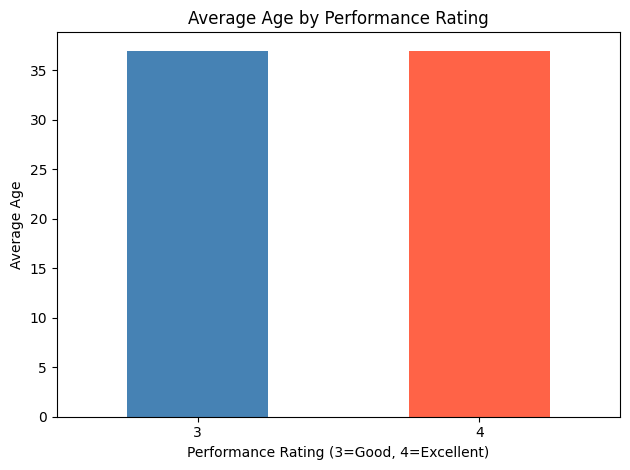

In [127]:
avg_age.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Average Age by Performance Rating')
plt.xlabel('Performance Rating (3=Good, 4=Excellent)')
plt.ylabel('Average Age')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**
- Both Good (3) and Excellent (4) performers have similar average age (36–37 years)
- Age alone does **not determine** performance rating
- Both young and old employees can achieve Excellent performance

---

### 2. Gender Analysis

**Analyze:** Average PerformanceRating by Gender

**Identify:**
- Does one gender dominate higher ratings?

In [ ]:
avg_gender = df.groupby('Gender')['PerformanceRating'].mean()
print(avg_gender)

In [ ]:
avg_gender.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Average Performance Rating by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**
- Average performance is **almost identical** for Male and Female employees
- Neither gender dominates higher ratings
- IBM shows gender-neutral performance distribution

---

### 3. Education Analysis

**Analyze:**
- PerformanceRating by Education Level
- EducationField vs Performance

**Identify:**
- Do higher-educated employees perform better?
- Does EducationField influence performance?

In [ ]:
edu_perf = df.groupby('Education')['PerformanceRating'].mean()
print(edu_perf)

In [ ]:
edu_perf.plot(kind='bar', color='cadetblue')
plt.title('Average Performance by Education Level')
plt.xlabel('Education (1=Below College, 2=College, 3=Bachelor, 4=Master, 5=Doctor)')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Performance is similar across all education levels. Higher education does **not guarantee** better performance.

---

In [ ]:
edu_field = df.groupby('EducationField')['PerformanceRating'].mean()
print(edu_field)

In [ ]:
edu_field.plot(kind='bar', color='mediumseagreen')
plt.title('Average Performance by Education Field')
plt.xlabel('Education Field')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

**Observation:** All education fields show similar performance ratings. Education field does **not strongly** influence performance.

---

### 4. Department Analysis

**Analyze:**
- Employee count per Department
- Average PerformanceRating per Department

**Identify:**
- High-performing and Low-performing departments

In [ ]:
dept_count = df['Department'].value_counts()
print(dept_count)

In [ ]:
dept_count.plot(kind='bar', color='coral')
plt.title('Employee Count per Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** R&D has most employees (~65%). Sales is second (~30%). HR is smallest (~5%).

---

In [ ]:
dept_perf = df.groupby('Department')['PerformanceRating'].mean()
print(dept_perf)

In [ ]:
dept_perf.plot(kind='bar', color='mediumpurple')
plt.title('Average Performance Rating per Department')
plt.xlabel('Department')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** All departments show similar average performance (~3.15). No department is significantly high or low performing.

---

### 5. Job Role & Job Level Analysis

**Analyze:**
- PerformanceRating per JobRole
- MonthlyIncome variation by JobRole

**Identify:**
- High-performance roles
- Does higher JobLevel guarantee higher performance?
- Are some roles underperforming consistently?

In [ ]:
jobrole_perf = df.groupby('JobRole')['PerformanceRating'].mean().sort_values(ascending=False)
print(jobrole_perf)

In [ ]:
jobrole_perf.plot(kind='bar', color='steelblue')
plt.title('Average Performance Rating by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observation:** Performance is similar across all job roles. No single role consistently outperforms or underperforms others.

---

In [ ]:
jobrole_income = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
print(jobrole_income)

In [ ]:
jobrole_income.plot(kind='bar', color='tomato')
plt.title('Average Monthly Income by Job Role')
plt.xlabel('Job Role')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

**Observation:** Manager and Research Director earn significantly more. Higher paid roles do **not** necessarily have higher performance ratings.

---

### 6. Promotion & Career Growth Analysis

**Features:** YearsSinceLastPromotion, PercentSalaryHike, TrainingTimesLastYear

**Analyze:**
- PerformanceRating vs YearsSinceLastPromotion
- PerformanceRating vs TrainingTimesLastYear

**Identify:**
- Does lack of promotion reduce performance?
- Are high performers rewarded with higher salary hikes?
- Does training frequency impact performance?

In [ ]:
promo_perf = df.groupby('PerformanceRating')['YearsSinceLastPromotion'].mean()
print(promo_perf)

In [ ]:
promo_perf.plot(kind='bar', color='darkorange')
plt.title('Average Years Since Last Promotion by Performance Rating')
plt.xlabel('Performance Rating (3=Good, 4=Excellent)')
plt.ylabel('Average Years Since Last Promotion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Excellent (4) performers were promoted slightly more recently. Employees not promoted for long show slightly lower performance — stagnant growth reduces motivation.

---

In [ ]:
training_perf = df.groupby('TrainingTimesLastYear')['PerformanceRating'].mean()
print(training_perf)

In [ ]:
training_perf.plot(kind='bar', color='indianred')
plt.title('Average Performance by Training Times Last Year')
plt.xlabel('Training Times Last Year')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Training frequency shows no strong pattern with performance. Attending more training sessions does **not guarantee** Excellent performance.

---

### 7. Workload & Overtime Analysis

**Features:** OverTime, BusinessTravel, JobInvolvement

**Analyze:**
- Overtime distribution (Yes/No)
- PerformanceRating for overtime employees
- Travel frequency vs PerformanceRating

**Identify:**
- Does overtime improve or reduce performance?
- Does frequent travel affect performance?

In [ ]:
overtime_perf = df.groupby('OverTime')['PerformanceRating'].mean()
print(overtime_perf)

In [ ]:
overtime_perf.plot(kind='bar', color='slategray')
plt.title('Average Performance by OverTime')
plt.xlabel('OverTime')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Overtime employees show similar performance. Working overtime does **not improve** performance rating.

---

In [ ]:
travel_perf = df.groupby('BusinessTravel')['PerformanceRating'].mean()
print(travel_perf)

In [ ]:
travel_perf.plot(kind='bar', color='cadetblue')
plt.title('Average Performance by Business Travel')
plt.xlabel('Business Travel')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Business travel frequency shows no significant difference in performance.

---

In [ ]:
involvement_perf = df.groupby('JobInvolvement')['PerformanceRating'].mean()
print(involvement_perf)

In [ ]:
involvement_perf.plot(kind='bar', color='mediumpurple')
plt.title('Average Performance by Job Involvement')
plt.xlabel('Job Involvement (1=Low to 4=Very High)')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Employees with higher job involvement (3 and 4) perform slightly better. Engaged employees tend to perform better.

---

### 8. Income & Compensation Analysis

**Features:** MonthlyIncome, StockOptionLevel

**Analyze:**
- MonthlyIncome vs PerformanceRating
- StockOptionLevel vs PerformanceRating

**Identify:**
- Are high performers paid more?
- Is compensation aligned with performance?

In [ ]:
income_perf = df.groupby('PerformanceRating')['MonthlyIncome'].mean()
print(income_perf)

In [ ]:
income_perf.plot(kind='bar', color='tomato')
plt.title('Average Monthly Income by Performance Rating')
plt.xlabel('Performance Rating (3=Good, 4=Excellent)')
plt.ylabel('Average Monthly Income')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Average income is very similar for both Good and Excellent performers. High salary does **not guarantee** Excellent performance.

---

In [ ]:
stock_perf = df.groupby('StockOptionLevel')['PerformanceRating'].mean()
print(stock_perf)

In [ ]:
stock_perf.plot(kind='bar', color='steelblue')
plt.title('Average Performance by Stock Option Level')
plt.xlabel('Stock Option Level (0=None to 3=High)')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Stock option level shows minimal difference in performance. Compensation is **not strongly aligned** with performance rating.

---

### 9. Attrition vs Performance Insight

**Analyze:**
- PerformanceRating vs Attrition
- Average performance of employees who left vs stayed

**Identify:**
- Are high performers leaving?
- Is poor performance linked to attrition?

In [ ]:
attr_perf = df.groupby('Attrition')['PerformanceRating'].mean()
print(attr_perf)

In [ ]:
attr_perf.plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Average Performance Rating: Stayed vs Left')
plt.xlabel('Attrition (No=Stayed, Yes=Left)')
plt.ylabel('Average Performance Rating')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Employees who left and stayed have almost **identical performance ratings**. High performers are also leaving IBM. Poor performance is **not the main reason** for attrition.

---

### 10. Feature Engineering Insights

**Create New Features:**
- `ExperienceRatio` = YearsAtCompany / (TotalWorkingYears + 1)
- `IncomePerYear` = MonthlyIncome / (TotalWorkingYears + 1)
- `StabilityIndex` = YearsWithCurrManager / (YearsAtCompany + 1)

In [ ]:
df['ExperienceRatio'] = df['YearsAtCompany'] / (df['TotalWorkingYears'] + 1)
df['IncomePerYear']   = df['MonthlyIncome']  / (df['TotalWorkingYears'] + 1)
df['StabilityIndex']  = df['YearsWithCurrManager'] / (df['YearsAtCompany'] + 1)

print("New features created!")
print("Shape:", df.shape)
df[['ExperienceRatio', 'IncomePerYear', 'StabilityIndex']].head()

In [ ]:
exp_perf = df.groupby('PerformanceRating')['ExperienceRatio'].mean()
exp_perf.plot(kind='bar', color='steelblue')
plt.title('ExperienceRatio by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Average Experience Ratio')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
inc_perf = df.groupby('PerformanceRating')['IncomePerYear'].mean()
inc_perf.plot(kind='bar', color='tomato')
plt.title('IncomePerYear by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Average Income Per Year')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
stab_perf = df.groupby('PerformanceRating')['StabilityIndex'].mean()
stab_perf.plot(kind='bar', color='mediumseagreen')
plt.title('StabilityIndex by Performance Rating')
plt.xlabel('Performance Rating')
plt.ylabel('Average Stability Index')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:**
- `ExperienceRatio` — fraction of career spent at IBM. Excellent performers show slightly higher ratio
- `IncomePerYear` — income per year of experience. Similar for both performance groups
- `StabilityIndex` — manager relationship stability. Similar for both groups

These new features help the ML model capture patterns that individual original features miss.

---

### EDA Summary

| Analysis | Key Finding |
|---|---|
| Age | Age does not determine performance |
| Gender | Both genders perform equally |
| Education | Higher education does not guarantee better performance |
| Department | All departments perform similarly |
| Job Role | No role consistently outperforms others |
| Promotion | Recently promoted employees perform slightly better |
| Overtime | Overtime does not improve performance |
| Income | High salary does not guarantee Excellent performance |
| Attrition | High performers also leave IBM |
| Feature Engineering | 3 new meaningful features created |

**Overall Conclusion:** No single factor strongly determines performance. The ML model must combine ALL features to achieve good accuracy (~84%).

---

## Bivariate Analysis

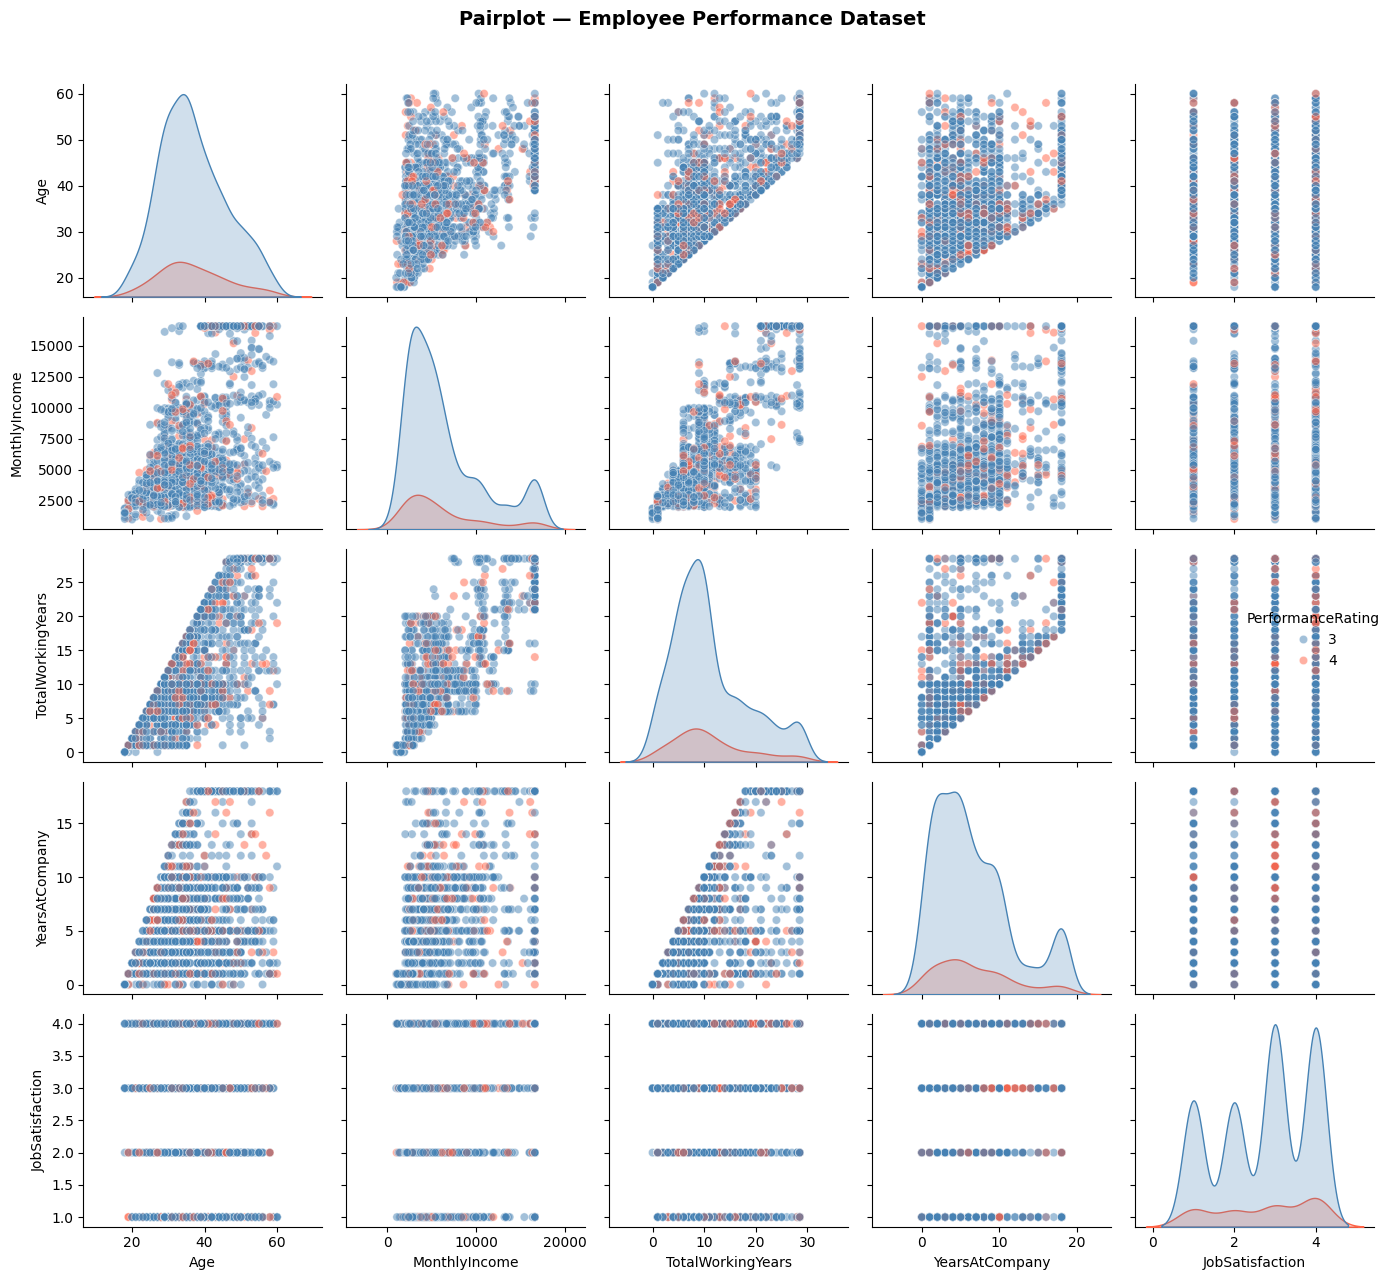

In [ ]:
# Pairplot — Bivariate Analysis
pair_cols = ['Age', 'MonthlyIncome', 'TotalWorkingYears',
             'YearsAtCompany', 'JobSatisfaction', 'PerformanceRating']

sns.pairplot(df[pair_cols], hue='PerformanceRating',
             palette={3: 'steelblue', 4: 'tomato'},
             diag_kind='kde', plot_kws={'alpha': 0.5})

plt.suptitle('Pairplot — Employee Performance Dataset',
             y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

- `Age vs MonthlyIncome` — Clear positive trend — older employees earn more. Red and blue points overlap heavily — income alone cannot separate classes
- `Age vs TotalWorkingYears` — Strong diagonal pattern — older employees have more experience (expected)
- `TotalWorkingYears vs MonthlyIncome` — Positive trend — more experience = higher income
- `YearsAtCompany vs TotalWorkingYears` — Triangular pattern — years at company cannot exceed total working years
- `JobSatisfaction` — Horizontal lines visible — discrete values (1,2,3,4) with heavy overlap between classes

**Overall Conclusion:**
- Blue (Good=3) and Red (Excellent=4) points **heavily overlap** in all scatter plots
- No single pair of features can cleanly separate the two performance classes
- This confirms that performance prediction is a **challenging task** requiring all features combined
- The ML model must learn complex patterns from **all features together** to achieve good accuracy


### Classifying Features into Four Levels

In [ ]:
# Classify features by measurement level

# Ordinal features — categorical with meaningful order
ordinal_features = ['Education', 'EnvironmentSatisfaction', 'JobInvolvement',
                    'JobSatisfaction', 'RelationshipSatisfaction',
                    'StockOptionLevel', 'WorkLifeBalance', 'PerformanceRating']

# Nominal features — categorical with no order
nominal_features = df.select_dtypes(include=['object']).columns.tolist()

# Ratio features — numeric with true zero point
ratio_features = ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
                  'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
                  'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
                  'YearsInCurrentRole', 'YearsSinceLastPromotion',
                  'YearsWithCurrManager']



In [ ]:
feature_levels_df = pd.DataFrame({
    'Feature': nominal_features + ordinal_features + ratio_features,
    'Measurement Level': (
        ['Nominal'] * len(nominal_features) +
        ['Ordinal'] * len(ordinal_features) +
        ['Ratio'] * len(ratio_features)
    )
})

print(f"Total features classified: {len(feature_levels_df)}")
feature_levels_df

Total features classified: 29


,Feature,Measurement Level
0,Attrition,Nominal
1,BusinessTravel,Nominal
2,Department,Nominal
3,EducationField,Nominal
4,Gender,Nominal
5,JobRole,Nominal
6,MaritalStatus,Nominal
7,OverTime,Nominal
8,Education,Ordinal
9,EnvironmentSatisfaction,Ordinal


### Explanation

The dataset features are classified into four levels of measurement based on
ordering, equal intervals, and the presence of a true zero.

- **Nominal:** Categorical features with no inherent order
  *Examples from this dataset:* Gender, Department, JobRole, Attrition, OverTime, MaritalStatus

- **Ordinal:** Categorical features with a meaningful order
  *Examples from this dataset:* Education (1=Below College to 5=Doctor),
  JobSatisfaction (1=Low to 4=Very High), WorkLifeBalance (1=Bad to 4=Best),
  PerformanceRating (3=Good, 4=Excellent)

- **Interval:** Numerical features with equal intervals but no true zero
  *Examples:* Temperature, Calendar Year
  *(No interval-level feature is present in this IBM HR dataset —
  all numeric columns have a true zero point)*

- **Ratio:** Numerical features with equal intervals and a true zero
  *Examples from this dataset:* Age, MonthlyIncome, YearsAtCompany,
  TotalWorkingYears, DistanceFromHome, TrainingTimesLastYear

### **Encoding Categorical Features**

In [ ]:
# Nominal features — text categories with no order
nominal_features = ['Attrition', 'BusinessTravel', 'Department',
                    'EducationField', 'Gender', 'JobRole',
                    'MaritalStatus', 'OverTime']

# Apply Label Encoding to all nominal features
le = LabelEncoder()

for col in nominal_features:
    df[col] = le.fit_transform(df[col])
    
print("Label Encoding applied to nominal features!")
print(f"Shape: {df.shape}")
df[nominal_features].head()

Label Encoding applied to nominal features!
Shape: (1470, 29)


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,OverTime
0,1,2,2,1,0,7,2,1
1,0,1,1,1,1,6,1,0
2,1,2,1,4,1,2,2,1
3,0,1,1,1,0,6,1,1
4,0,2,1,3,1,2,1,0


Machine learning models work with numbers, not text.
So we must convert categorical columns into numeric form. Thus, Encoding of categorical features is performed.
We use Label Encoding instead of One-Hot Encoding because: Label Encoding keeps all features in their original columns

### Scaling

In [ ]:
df.dtypes

Age                           int64
Attrition                     int64
BusinessTravel                int64
DailyRate                     int64
Department                    int64
DistanceFromHome              int64
Education                     int64
EducationField                int64
EnvironmentSatisfaction       int64
Gender                        int64
HourlyRate                    int64
JobInvolvement                int64
JobRole                       int64
JobSatisfaction               int64
MaritalStatus                 int64
MonthlyIncome                 int64
MonthlyRate                   int64
NumCompaniesWorked          float64
OverTime                      int64
PerformanceRating             int64
RelationshipSatisfaction      int64
StockOptionLevel              int64
TotalWorkingYears           float64
TrainingTimesLastYear       float64
WorkLifeBalance               int64
YearsAtCompany                int64
YearsInCurrentRole          float64
YearsSinceLastPromotion     

In [ ]:

print("NaN values before fix:")
print(df[numeric_cols_to_scale].isnull().sum())

# Fill NaN with median of each column
df[numeric_cols_to_scale] = df[numeric_cols_to_scale].fillna(df[numeric_cols_to_scale].median())

print("\nNaN values after fix:")
print(df[numeric_cols_to_scale].isnull().sum())
print(f"\nShape: {df.shape}")

NaN values before fix:
Age                        0
DailyRate                  0
DistanceFromHome           0
HourlyRate                 0
MonthlyIncome              0
MonthlyRate                0
NumCompaniesWorked         0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

NaN values after fix:
Age                        0
DailyRate                  0
DistanceFromHome           0
HourlyRate                 0
MonthlyIncome              0
MonthlyRate                0
NumCompaniesWorked         0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsInCurrentRole         0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

Shape: (1470, 29)


In [ ]:
# Apply log1p to highly skewed features BEFORE scaling
skewed_cols = ['MonthlyIncome', 'NumCompaniesWorked', 'TotalWorkingYears',
               'YearsAtCompany', 'YearsInCurrentRole',
               'YearsSinceLastPromotion', 'YearsWithCurrManager']

for col in skewed_cols:
    df[col] = np.log1p(df[col])

print("Log1p transformation applied to skewed features!")

Log1p transformation applied to skewed features!


In [ ]:
from sklearn.preprocessing import StandardScaler

# Numeric columns to scale in IBM HR Dataset
numeric_cols_to_scale = [
    'Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate',
    'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
    'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany',
    'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager'
]

scaler = StandardScaler()
df[numeric_cols_to_scale] = scaler.fit_transform(df[numeric_cols_to_scale])

# Save scaler for demo
import pickle
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("StandardScaler applied successfully!")
print("Scaler saved as 'scaler.pkl'")
print(f"\nShape: {df.shape}")
df[numeric_cols_to_scale].head()

StandardScaler applied successfully!
Scaler saved as 'scaler.pkl'

Shape: (1470, 29)


,Age,DailyRate,DistanceFromHome,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0.446350,0.742527,-1.010909,1.383138,0.236763,0.726020,1.671048,-0.132886,-2.130765,0.207794,0.293106,-1.004735,0.550337
1,1.322365,-1.297775,-0.147150,-0.240677,-0.002715,1.488876,-0.586545,0.158324,0.278639,0.829923,0.886909,-0.092560,0.908023
2,0.008343,1.414363,-0.887515,1.284725,-1.385524,-1.674841,1.293830,-0.303811,0.278639,-2.470625,-1.740262,-1.004735,-1.677428
3,-0.429664,1.461466,-0.764121,-0.486709,-0.876385,1.243211,-0.586545,-0.132886,0.278639,0.553712,0.886909,0.819614,-1.677428
4,-1.086676,-0.524295,-0.887515,-1.274014,-0.605705,0.325900,1.752202,-0.497590,0.278639,-0.958456,-0.352273,0.441028,-0.311480



KEY INSIGHT FROM STEPS DONE IN SCALING

- Log1p transformation successfully reduced skewness in 5 highly skewed features
- StandardScaler equalized all feature ranges to mean=0, std=1
- NaN values were filled with median before scaling
- All 1470 rows preserved — no data lost
- Scaler saved as `scaler.pkl` for future demo prediction
